# ECC Model Analysis
Economic Carrying Capacity model with spatial land allocation.

**Files needed in the same folder:**
- `ecc_parameters.py`
- `ecc_optimization.py`
- `spatial_g.py`
- `hcc_spatial_input.mat`

## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from datetime import datetime

from ecc_parameters import get_parameters
from ecc_optimization import ecc_optimization
from spatial_g import (
    load_spatial_data,
    get_kcal_per_ha,
    compute_effective_g,
    effective_par_from_g
)

print('imports ok')

imports ok


## 2. Load Spatial Data

In [2]:
PAR_grid, area, farmedPct, eimat, is_land = load_spatial_data()
area_ha = area / 10000

ei_mean = np.mean(eimat, axis=2)
is_land = (ei_mean > 0) & (farmedPct > 0)
print(f'farmable land cells: {is_land.sum()} of {180*360}')

print(f'PAR shape:       {PAR_grid.shape}')
print(f'area shape:      {area.shape}')
print(f'farmedPct shape: {farmedPct.shape}')
print(f'land cells:      {is_land.sum()} of {180*360}')
print(f'total area:      {np.nansum(area_ha)/1e9:.2f} Gha')
print(f'farmed area:     {np.nansum(farmedPct*area_ha)/1e9:.2f} Gha')
print(f'current farmed share: {np.nansum(farmedPct*area_ha)/np.nansum(area_ha):.4f}')

farmable land cells: 9598 of 64800
PAR shape:       (180, 360, 365)
area shape:      (180, 360)
farmedPct shape: (180, 360)
land cells:      9598 of 64800
total area:      51.01 Gha
farmed area:     4.21 Gha
current farmed share: 0.0825


## 3. Effective g vs Land Share
Shows how food productivity decreases as more land is brought into production (diminishing returns).

average PAR across all land: 106140403.47 kcal/ha/yr
aspatial g = 127262808 kcal/ha/yr

  share=0.05 -> g=173196703 kcal/ha/yr
  share=0.10 -> g=170899947 kcal/ha/yr
  share=0.15 -> g=168229263 kcal/ha/yr
  share=0.20 -> g=165685560 kcal/ha/yr
  share=0.25 -> g=163412064 kcal/ha/yr
  share=0.30 -> g=161569094 kcal/ha/yr
  share=0.35 -> g=159961062 kcal/ha/yr
  share=0.40 -> g=158412269 kcal/ha/yr
  share=0.45 -> g=156893863 kcal/ha/yr
  share=0.50 -> g=155428978 kcal/ha/yr
  share=0.55 -> g=153980304 kcal/ha/yr
  share=0.60 -> g=152528301 kcal/ha/yr
  share=0.65 -> g=151082965 kcal/ha/yr
  share=0.70 -> g=149593022 kcal/ha/yr
  share=0.75 -> g=148022568 kcal/ha/yr
  share=0.80 -> g=146314774 kcal/ha/yr
  share=0.85 -> g=144523655 kcal/ha/yr
  share=0.90 -> g=142511168 kcal/ha/yr
  share=0.95 -> g=139402392 kcal/ha/yr
  share=1.00 -> g=134584841 kcal/ha/yr


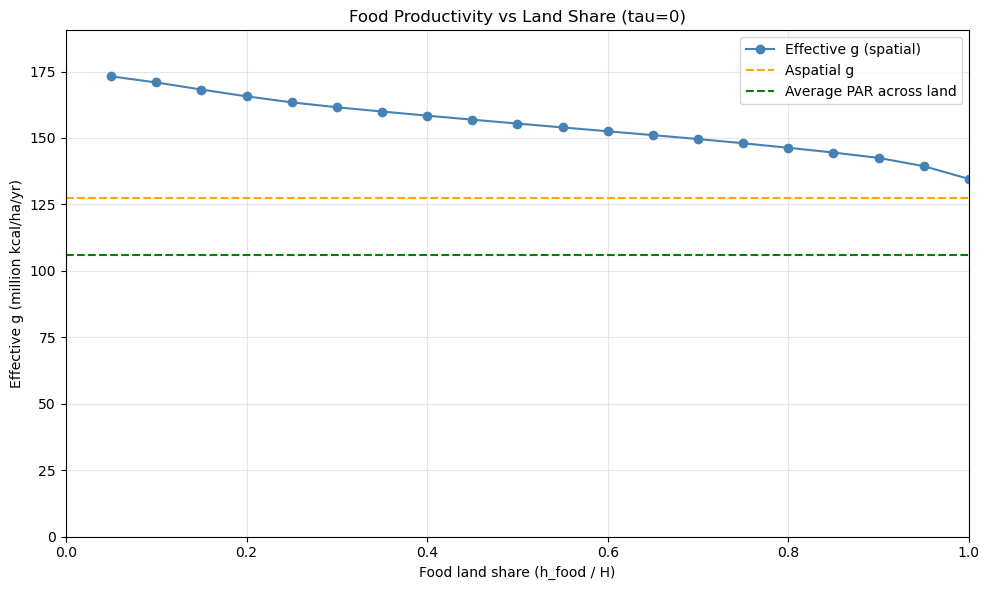

In [3]:
tau = 0.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)

# average PAR across whole land area
avg_par = np.nansum(kcal_per_ha * area) / np.nansum(area)
print(f'average PAR across all land: {avg_par:.2f} kcal/ha/yr')

# aspatial reference
conversion = tau * (0.123 - 0.123/2.5) + 0.123/2.5
harvest    = 1 - (tau * (0 - 0.5) + 0.5)
g_aspatial = 2164.5 * 239.006 * 10000 * harvest * conversion

# full range 0 to 1
shares   = np.arange(0.05, 1.05, 0.05)
g_values = [compute_effective_g(kcal_per_ha, area_ha, farmedPct, s, is_land) for s in shares]

print(f'aspatial g = {g_aspatial:.0f} kcal/ha/yr')
print()
for s, g in zip(shares, g_values):
    print(f'  share={s:.2f} -> g={g:.0f} kcal/ha/yr')

plt.figure(figsize=(10, 6))
plt.axis([0, 1, 0, max(g_values) * 1.1 / 1e6])
plt.plot(shares, np.array(g_values) / 1e6, 'o-', color='steelblue', label='Effective g (spatial)')
plt.axhline(g_aspatial / 1e6, color='orange', linestyle='--', label='Aspatial g')
plt.axhline(avg_par / 1e6,    color='green',  linestyle='--', label='Average PAR across land')
plt.xlabel('Food land share (h_food / H)')
plt.ylabel('Effective g (million kcal/ha/yr)')
plt.title('Food Productivity vs Land Share (tau=0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('effective_g_vs_share.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# fit linear relationship
from numpy.polynomial import polynomial as P

shares_fit = np.arange(0.05, 1.05, 0.05)
g_fit      = [compute_effective_g(kcal_per_ha, area_ha, farmedPct, s, is_land) 
              for s in shares_fit]

coeffs = np.polyfit(shares_fit, g_fit, 1)  
slope, intercept = coeffs
print(f'g(h_food) ≈ {intercept:.0f} + {slope:.0f} * h_food')
print(f'R² = {np.corrcoef(shares_fit, g_fit)[0,1]**2:.4f}')

g(h_food) ≈ 179790191 + -45499020 * h_food
R² = 0.9637


Linear fit: g(h_food) = 179790191 + -45499020 * h_food
R² = 0.9637


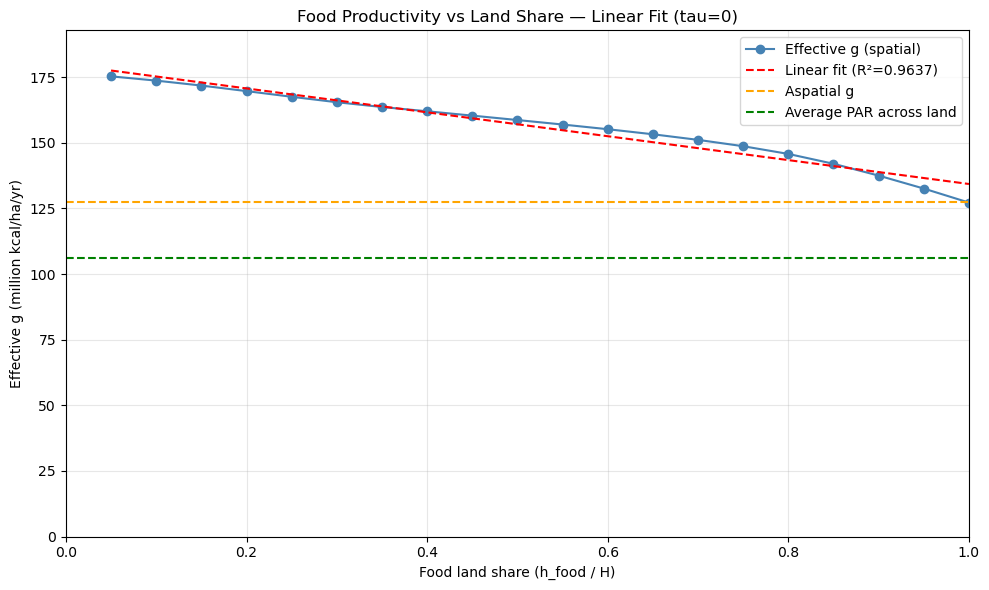

In [ ]:
# fit linear relationship
coeffs    = np.polyfit(shares, g_values, 1)
slope     = coeffs[0]
intercept = coeffs[1]
r_squared = np.corrcoef(shares, g_values)[0,1]**2

print(f'Linear fit: g(h_food) = {intercept:.0f} + {slope:.0f} * h_food')
print(f'R² = {r_squared:.4f}')

g_fitted = np.polyval(coeffs, shares)

plt.figure(figsize=(10, 6))
plt.axis([0, 1, 0, max(g_values) * 1.1 / 1e6])
plt.plot(shares, np.array(g_values) / 1e6, 'o-', color='steelblue', label='Effective g (spatial)')
plt.plot(shares, g_fitted / 1e6, 'r--', label=f'Linear fit (R²={r_squared:.4f})')
plt.axhline(g_aspatial / 1e6, color='orange', linestyle='--', label='Aspatial g')
plt.axhline(avg_par / 1e6,    color='green',  linestyle='--', label='Average PAR across land')
plt.xlabel('Food land share (h_food / H)')
plt.ylabel('Effective g (million kcal/ha/yr)')
plt.title('Food Productivity vs Land Share — Linear Fit (tau=0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('effective_g_linear_fit.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
print(f'slope:     {slope:.2f} kcal/ha/yr per unit share')
print(f'intercept: {intercept:.2f} kcal/ha/yr')
print(f'at h_food=0.21 (spatial result): g = {intercept + slope*0.21:.0f}')
print(f'at h_food=0.24 (aspatial result): g = {intercept + slope*0.24:.0f}')
print(f'aspatial g scalar: 127,262,808')

slope:     -45499019.95 kcal/ha/yr per unit share
intercept: 179790191.11 kcal/ha/yr
at h_food=0.21 (spatial result): g = 170235397
at h_food=0.24 (aspatial result): g = 168870426
aspatial g scalar: 127,262,808


In [72]:
# compute linear fit coefficients for each tau level
tau_values = np.arange(0.0, 1.1, 0.1)
fit_coeffs = {}

for tau_fit in tau_values:
    kcal_fit, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau_fit)
    shares_fit  = np.arange(0.05, 1.05, 0.05)
    g_fit       = [compute_effective_g(kcal_fit, area_ha, farmedPct, s, is_land) 
                   for s in shares_fit]
    coeffs      = np.polyfit(shares_fit, g_fit, 1)
    r2          = np.corrcoef(shares_fit, g_fit)[0,1]**2
    fit_coeffs[round(tau_fit, 1)] = {'slope': coeffs[0], 'intercept': coeffs[1], 'r2': r2}
    print(f'tau={tau_fit:.1f}: g = {coeffs[1]:.0f} + {coeffs[0]:.0f} * h_food  (R²={r2:.4f})')

tau=0.0: g = 179790191 + -45499020 * h_food  (R²=0.9637)
tau=0.1: g = 227434592 + -57556260 * h_food  (R²=0.9637)
tau=0.2: g = 280472698 + -70978471 * h_food  (R²=0.9637)
tau=0.3: g = 338904510 + -85765653 * h_food  (R²=0.9637)
tau=0.4: g = 402730028 + -101917805 * h_food  (R²=0.9637)
tau=0.5: g = 471949252 + -119434927 * h_food  (R²=0.9637)
tau=0.6: g = 546562181 + -138317021 * h_food  (R²=0.9637)
tau=0.7: g = 626568816 + -158564085 * h_food  (R²=0.9637)
tau=0.8: g = 711969157 + -180176119 * h_food  (R²=0.9637)
tau=0.9: g = 802763203 + -203153124 * h_food  (R²=0.9637)
tau=1.0: g = 898950956 + -227495100 * h_food  (R²=0.9637)


In [73]:
# check if slope/intercept ratio is constant across tau
print('slope/intercept ratio across tau:')
for tau_fit, c in fit_coeffs.items():
    ratio = c['slope'] / c['intercept']
    print(f'  tau={tau_fit}: {ratio:.6f}')

slope/intercept ratio across tau:
  tau=0.0: -0.253067
  tau=0.1: -0.253067
  tau=0.2: -0.253067
  tau=0.3: -0.253067
  tau=0.4: -0.253067
  tau=0.5: -0.253067
  tau=0.6: -0.253067
  tau=0.7: -0.253067
  tau=0.8: -0.253067
  tau=0.9: -0.253067
  tau=1.0: -0.253067


## 4. Single Point Test — Spatial vs Aspatial
Test at the point specified by advisor: tau=0, pop=8 billion.

In [4]:
# Scenario A: Optimally choose farms, choose best first
def get_analytic_sols(params):
    mu0, mu1 = params['mu0'], params['mu1']
    g0,g1,g2,g3 = params['gamma0'],params['gamma1'],params['gamma2'],params['gamma3']
    a0,a1,a2    = params['alpha0'],params['alpha1'],params['alpha2']
    e0,e1       = params['eta0'],params['eta1']
    kd = a0*mu1 + mu0*g0 + e0*(mu0*g2 + mu1*a2)
    ld = a1*mu1 + mu0*g1 + e1*(mu0*g2 + mu1*a2)
    nd = mu0*g2 + mu1*a2
    hd = 1 + a2 + mu0*(g3 + g2 - 1 - a2)
    return np.array([
        g0*mu0/kd, a0*mu1/kd, e0*(mu0*g2+mu1*a2)/kd,
        g1*mu0/ld, a1*mu1/ld, e1*(mu0*g2+mu1*a2)/ld,
        mu0*g2/nd, mu1*a2/nd,
        mu0*g3/hd, mu1/hd, (mu0*g2+mu1*a2)/hd
    ])

def setup_params(pop, tau, params, sols, use_spatial=True,
                 kcal_per_ha=None, area_ha=None, farmedPct=None, is_land=None):
    p = params.copy()
    p['sols'] = sols
    L   = p['lfpr'] * pop
    ece = tau * (0.868 - 0.22) + 0.22
    if use_spatial:
        h_food = sols[9]
        eff_g  = compute_effective_g(kcal_per_ha, area_ha, farmedPct, h_food, is_land)
        p['PAR'] = effective_par_from_g(eff_g, tau)
    nmax  = ece * p['PAR'] * sols[10] * (p['H']/L) * sols[2]**p['eta0'] * sols[5]**p['eta1']
    Omega = p['A'] * sols[0]**p['gamma0'] * sols[3]**p['gamma1'] * (sols[6]*nmax)**p['gamma2'] * (sols[8]*(p['H']/L))**p['gamma3']
    kmax  = (p['s']/p['d'] * Omega)**(1/(1-p['gamma0']))
    p['nmax'] = nmax
    p['kmax'] = kmax
    return p

# single point test: tau=0, pop=8
tau = 0.0
pop = 8.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)

params = get_parameters()
sols   = get_analytic_sols(params)

# spatial
p_spatial = setup_params(pop, tau, params, sols, use_spatial=True,
                         kcal_per_ha=kcal_per_ha, area_ha=area_ha,
                         farmedPct=farmedPct, is_land=is_land)
sol_s, util_s, flag_s = ecc_optimization(pop, tau, p_spatial)

# aspatial
p_aspatial = setup_params(pop, tau, params, sols, use_spatial=False)
sol_a, util_a, flag_a = ecc_optimization(pop, tau, p_aspatial)

print(f'tau={tau}, pop={pop}B')
print(f'  Spatial:  exitflag={flag_s}, utility={-util_s:.6f}, h_food={sol_s[9]:.4f}')
print(f'  Aspatial: exitflag={flag_a}, utility={-util_a:.6f}, h_food={sol_a[9]:.4f}')
print(f'  Difference: {(-util_s - (-util_a)):.6f} ({(-util_s/(-util_a)-1)*100:.2f}%)')

# check actual hectares vs farmed area
H = params['H'] * 1e9
food_ha_spatial  = sol_s[9] * H
food_ha_aspatial = sol_a[9] * H
farmed_ha        = np.nansum(farmedPct * area_ha)

print(f'\nLand use breakdown:')
print(f'  H (total model land):   {H/1e9:.2f} Gha')
print(f'  food land spatial:      {food_ha_spatial/1e9:.2f} Gha')
print(f'  food land aspatial:     {food_ha_aspatial/1e9:.2f} Gha')
print(f'  current farmed area:    {farmed_ha/1e9:.2f} Gha')
print(f'  food < farmed? spatial={food_ha_spatial < farmed_ha}, aspatial={food_ha_aspatial < farmed_ha}')
print(f'  spatial uses {food_ha_spatial/farmed_ha*100:.1f}% of current farmed area')
print(f'  aspatial uses {food_ha_aspatial/farmed_ha*100:.1f}% of current farmed area')

tau=0.0, pop=8.0B
  Spatial:  exitflag=1, utility=7.413301, h_food=0.2154
  Aspatial: exitflag=1, utility=7.244839, h_food=0.2438
  Difference: 0.168462 (2.33%)

Land use breakdown:
  H (total model land):   4.91 Gha
  food land spatial:      1.06 Gha
  food land aspatial:     1.20 Gha
  current farmed area:    4.21 Gha
  food < farmed? spatial=True, aspatial=True
  spatial uses 25.2% of current farmed area
  aspatial uses 28.5% of current farmed area


In [5]:
# Scenario B: fixed farmed-area-weighted average g 
def compute_effective_g_scenB(kcal_per_ha, area_ha, farmedPct, is_land):
    """
    Returns the production-weighted average g across ALL currently
    farmed land — no selection, no diminishing returns.
    This gives a fixed g regardless of how much land the optimizer uses.
    """
    farmed_area = farmedPct.ravel() * area_ha.ravel() * is_land.ravel()
    return float(np.nansum(kcal_per_ha.ravel() * farmed_area) / np.nansum(farmed_area))

tau = 0.0
pop = 8.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)
params = get_parameters()
sols   = get_analytic_sols(params)

eff_g_B = compute_effective_g_scenB(kcal_per_ha, area_ha, farmedPct, is_land)
print(f'Scenario B effective g: {eff_g_B:.0f} kcal/ha/yr')
print(f'Aspatial g:             127262808 kcal/ha/yr')
print(f'Scenario A g (best 25%): ~152000000 kcal/ha/yr')
print()

p_B = setup_params(pop, tau, params, sols, use_spatial=False)
p_B['PAR'] = effective_par_from_g(eff_g_B, tau)
L   = p_B['lfpr'] * pop
ece = tau * (0.868 - 0.22) + 0.22
nmax  = ece * p_B['PAR'] * sols[10] * (p_B['H']/L) * sols[2]**p_B['eta0'] * sols[5]**p_B['eta1']
Omega = p_B['A'] * sols[0]**p_B['gamma0'] * sols[3]**p_B['gamma1'] * (sols[6]*nmax)**p_B['gamma2'] * (sols[8]*(p_B['H']/L))**p_B['gamma3']
p_B['kmax'] = (p_B['s']/p_B['d'] * Omega)**(1/(1-p_B['gamma0']))
p_B['nmax'] = nmax

sol_B, util_B, flag_B = ecc_optimization(pop, tau, p_B)

print(f'tau={tau}, pop={pop}B')
print(f'  Scenario A (best farms): utility={7.403959:.6f}')
print(f'  Scenario B (avg farms):  utility={-util_B:.6f},  exitflag={flag_B}')
print(f'  Aspatial:                utility={7.244839:.6f}')
print()
print('Summary:')
print(f'  Scenario A spatial > aspatial: picks best farms, needs less land')
print(f'  Scenario B spatial < aspatial: uses true avg productivity, lower than scalar')

Scenario B effective g: 132887275 kcal/ha/yr
Aspatial g:             127262808 kcal/ha/yr
Scenario A g (best 25%): ~152000000 kcal/ha/yr

tau=0.0, pop=8.0B
  Scenario A (best farms): utility=7.403959
  Scenario B (avg farms):  utility=7.271110,  exitflag=1
  Aspatial:                utility=7.244839

Summary:
  Scenario A spatial > aspatial: picks best farms, needs less land
  Scenario B spatial < aspatial: uses true avg productivity, lower than scalar


In [6]:
# what is the productivity-weighted average over ALL land in H?
# H = 4.91 Gha of developed/agricultural land
# this should be close to what aspatial PAR=2164.5 represents

tau = 0.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)

# weighted average over all land cells (not just farmed)
land_area = area_ha * is_land
g_all_land = np.nansum(kcal_per_ha * land_area) / np.nansum(land_area)

# weighted average over farmed cells only
farmed_area = farmedPct * area_ha * is_land
g_farmed = np.nansum(kcal_per_ha * farmed_area) / np.nansum(farmed_area)

# aspatial reference
conversion = tau * (0.123 - 0.123/2.5) + 0.123/2.5
harvest    = 1 - (tau * (0 - 0.5) + 0.5)
g_aspatial = 2164.5 * 239.006 * 10000 * harvest * conversion

print(f'g all land:   {g_all_land:.0f} kcal/ha/yr')
print(f'g farmed:     {g_farmed:.0f} kcal/ha/yr')
print(f'g aspatial:   {g_aspatial:.0f} kcal/ha/yr')

g all land:   134584841 kcal/ha/yr
g farmed:     132887275 kcal/ha/yr
g aspatial:   127262808 kcal/ha/yr


## Key Result — Income and Substitution Effects Confirmed (tau=0, pop=8B)

Spatial vs aspatial comparison:
- Calorie production proxy (g × h_food): +16.3% spatial
- Land in food: -12.5% spatial  
- Land in goods: +4.2% spatial
- Utility: +2.5% spatial

Interpretation: The spatial model selects above-average agricultural land,
making food cheaper to produce. This generates both an income effect
(more calories produced) and a substitution effect (less land needed for food,
more available for goods). Result is consistent with advisor's prediction.

## 5. Food Productivity Map

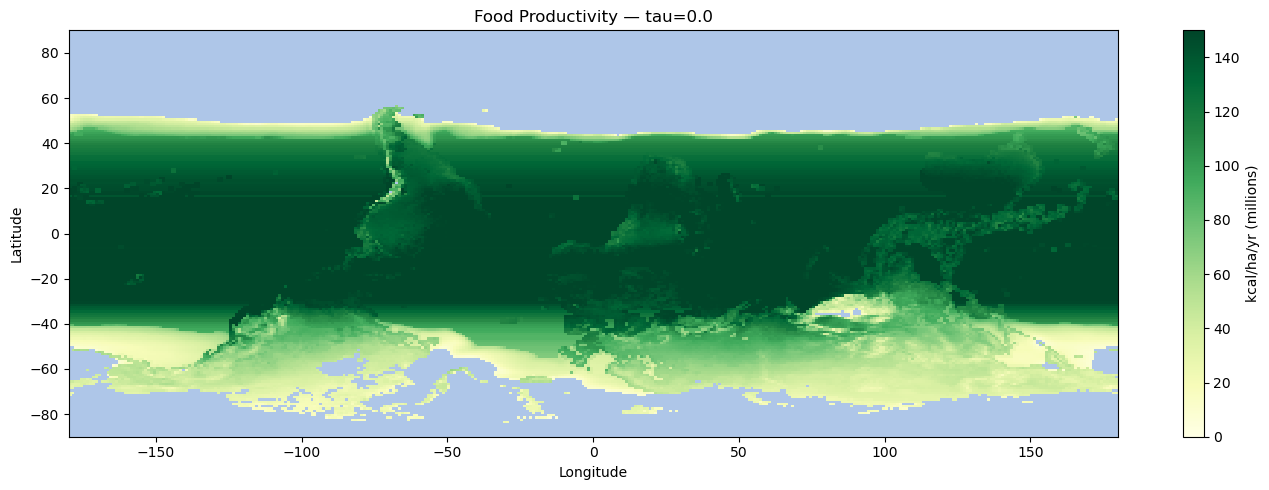

saved to food_productivity_map.png


In [66]:
lon = np.linspace(-179.5, 179.5, 360)
lat = np.linspace(89.5, -89.5, 180)
lon2d, lat2d = np.meshgrid(lon, lat)

# mask ocean cells
g_masked = np.where(is_land, kcal_per_ha, np.nan)

plt.figure(figsize=(14, 5))
plt.xlim(-180, 180)
plt.ylim(-90, 90)
im = plt.pcolormesh(lon2d, lat2d, g_masked/1e6, cmap='YlGn', shading='auto', vmin=0, vmax=150)
plt.colorbar(im, label='kcal/ha/yr (millions)')
plt.title(f'Food Productivity — tau={tau}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().set_facecolor('#aec6e8')  # ocean blue
plt.tight_layout()
plt.savefig('food_productivity_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to food_productivity_map.png')

## 6. Land Allocation Map

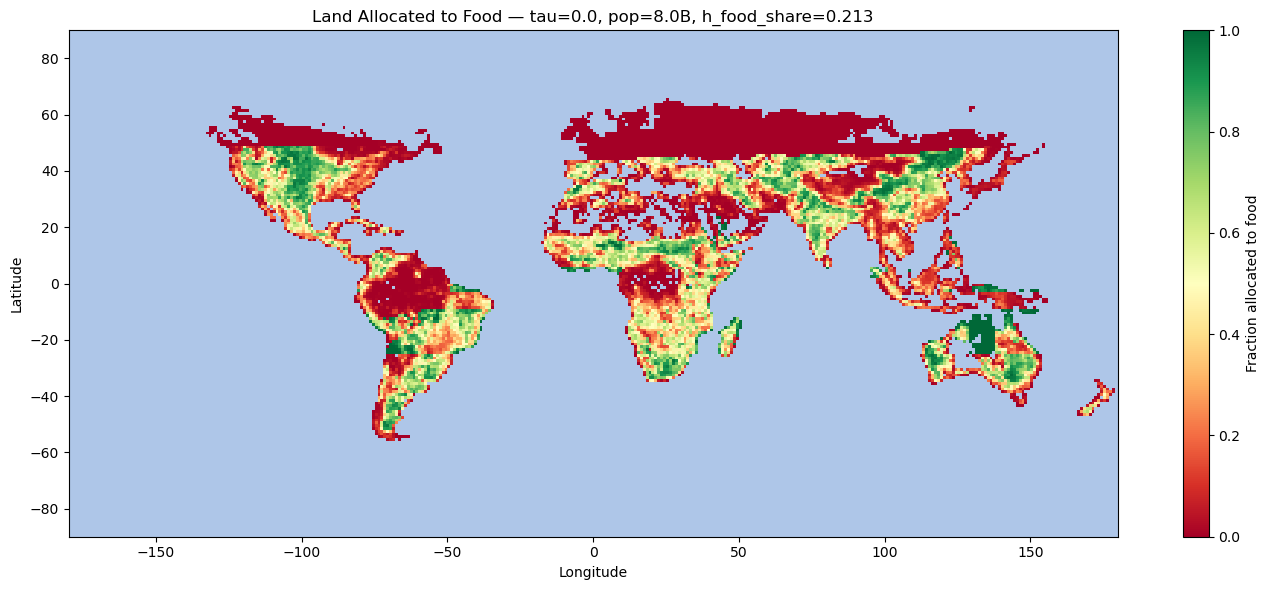

saved to land_allocation_map.png


In [68]:
h_food_share = sol_s[9]  # optimal food share from spatial result
total_ha  = np.nansum(area_ha)
target_ha = h_food_share * total_ha

g_flat      = kcal_per_ha.ravel()
area_flat   = area_ha.ravel()
farmed_flat = farmedPct.ravel()
land_flat   = is_land.ravel()
order       = np.argsort(-g_flat)

farmed_area   = farmed_flat * area_flat * land_flat
unfarmed_area = (1 - farmed_flat) * area_flat * land_flat
selected      = np.zeros(len(g_flat))
accumulated   = 0.0

for idx in order:
    if farmed_area[idx] <= 0: continue
    if accumulated >= target_ha: break
    take = min(farmed_area[idx], target_ha - accumulated)
    selected[idx] = take / area_flat[idx]
    accumulated  += take

for idx in order:
    if unfarmed_area[idx] <= 0: continue
    if accumulated >= target_ha: break
    take = min(unfarmed_area[idx], target_ha - accumulated)
    selected[idx] = take / area_flat[idx]
    accumulated  += take

selected_2d = np.where(farmedPct > 0, selected.reshape(180, 360), np.nan)

plt.figure(figsize=(14, 6))
im = plt.pcolormesh(lon2d, lat2d, selected_2d, cmap='RdYlGn', shading='auto', vmin=0, vmax=1)
plt.colorbar(im, label='Fraction allocated to food')
plt.title(f'Land Allocated to Food — tau={tau}, pop={pop}B, h_food_share={h_food_share:.3f}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.gca().set_facecolor('#aec6e8')
plt.tight_layout()
plt.savefig('land_allocation_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to land_allocation_map.png')

tau=1.0, pop=8.0B: exitflag=1, utility=8.2229, h_food=0.1439


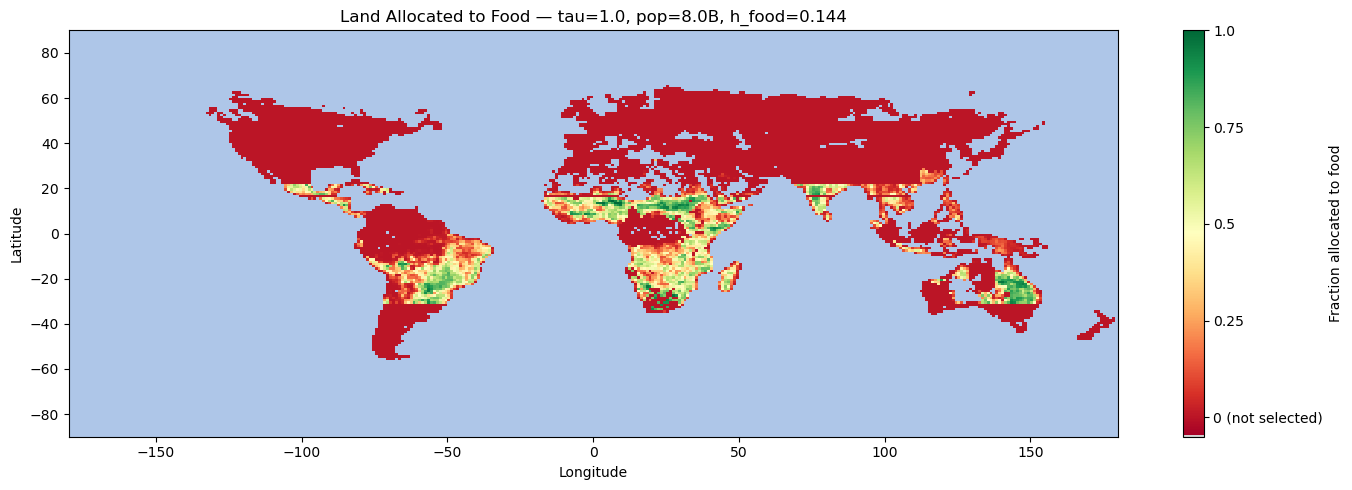

total selected: 1.51 Gha of 10.49 Gha farmable


In [ ]:
# scenario testing: only change below 2 numbers to explore scenarios
tau_test = 1.0
pop_test = 8.0
# ----------------------------------------
kcal_per_ha_test, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau_test)
params_test = get_parameters()
sols_test   = get_analytic_sols(params_test)
p_test      = setup_params(pop_test, tau_test, params_test, sols_test,
                           use_spatial=True, kcal_per_ha=kcal_per_ha_test,
                           area_ha=area_ha, farmedPct=farmedPct, is_land=is_land)
sol_test, util_test, flag_test = ecc_optimization(pop_test, tau_test, p_test)
h_food_share_test = sol_test[9]
print(f'tau={tau_test}, pop={pop_test}B: exitflag={flag_test}, utility={-util_test:.4f}, h_food={h_food_share_test:.4f}')

g_flat_test   = kcal_per_ha_test.ravel()
area_flat     = area_ha.ravel()
farmed_flat   = farmedPct.ravel()
land_flat     = is_land.ravel()
farmable      = (farmed_flat > 0) & land_flat
unfarmed_land = (farmed_flat == 0) & land_flat
total_ha_test = np.nansum(area_flat * land_flat)
target_ha     = h_food_share_test * total_ha_test
farmed_area   = farmed_flat * area_flat * farmable
unfarmed_area = area_flat * unfarmed_land
order         = np.argsort(-g_flat_test)
selected      = np.zeros(len(g_flat_test))
accumulated   = 0.0
for idx in order:
    if farmed_area[idx] <= 0: continue
    if accumulated >= target_ha: break
    take = min(farmed_area[idx], target_ha - accumulated)
    selected[idx] = take / area_flat[idx]
    accumulated  += take
for idx in order:
    if unfarmed_area[idx] <= 0: continue
    if accumulated >= target_ha: break
    take = min(unfarmed_area[idx], target_ha - accumulated)
    selected[idx] = take / area_flat[idx]
    accumulated  += take

selected_2d = selected.reshape(180, 360)
display_2d  = np.where(farmedPct > 0, selected_2d,
              np.where(is_land, -0.05, np.nan))
colors_list = ['#d3d3d3'] + list(plt.cm.RdYlGn(np.linspace(0, 1, 256)))
custom_cmap = LinearSegmentedColormap.from_list('grey_RdYlGn', colors_list, N=257)
plt.figure(figsize=(14, 5))
im = plt.pcolormesh(lon2d, lat2d, display_2d, cmap=custom_cmap, shading='auto', vmin=-0.05, vmax=1)
cbar = plt.colorbar(im, label='Fraction allocated to food')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0 (not selected)', '0.25', '0.5', '0.75', '1.0'])
plt.title(f'Land Allocated to Food — tau={tau_test}, pop={pop_test}B, h_food={h_food_share_test:.3f}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().set_facecolor('#aec6e8')
plt.tight_layout()
plt.savefig(f'land_allocation_tau{tau_test}_pop{int(pop_test)}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'total selected: {np.nansum(selected*area_flat)/1e9:.2f} Gha of {np.nansum(area_flat*farmable)/1e9:.2f} Gha farmable')

**Update: I may be able to use matplotlibs to create a way to click on the heatmap produced in ecc_makefigs to see the corresponding land allocation maps

## 7. Small Grid Run — Spatial Model
Runs the optimizer across a small (tau, pop) grid and saves results. -- Likely will run this later as I finalize model on single points

In [75]:
def solve_one_point(tech, population, params, sols,
                    kcal_per_ha, area_ha, farmedPct, is_land,
                    max_iter=50, damping=0.6):
    """
    Solves a single (tau, pop) point with the spatial g,
    updating effective PAR at each fixed-point iteration.
    """
    p   = params.copy()
    p['sols'] = sols
    L   = p['lfpr'] * population
    ece = tech * (0.868 - 0.22) + 0.22

    # initial setup
    h_food = sols[9]
    eff_g  = compute_effective_g(kcal_per_ha, area_ha, farmedPct, h_food, is_land)
    p['PAR'] = effective_par_from_g(eff_g, tech)

    nmax  = ece * p['PAR'] * sols[10] * (p['H']/L) * sols[2]**p['eta0'] * sols[5]**p['eta1']
    Omega = p['A'] * sols[0]**p['gamma0'] * sols[3]**p['gamma1'] * (sols[6]*nmax)**p['gamma2'] * (sols[8]*(p['H']/L))**p['gamma3']
    kmax  = (p['s']/p['d'] * Omega)**(1/(1-p['gamma0']))
    p['nmax'] = nmax
    p['kmax'] = kmax

    tolerance = 1e-4 if L <= 1 else 1e-5 * max(1, population/25)

    for _ in range(max_iter):
        try:
            soltemp, utiltemp, exitflag = ecc_optimization(population, tech, p)
        except:
            return np.full(11, -np.inf), -np.inf, -1

        if exitflag == -2:
            return np.full(11, np.nan), np.nan, -2
        elif exitflag <= 0:
            return np.full(11, -np.inf), -np.inf, exitflag

        # update effective g from current food share
        h_food = soltemp[9]
        eff_g  = compute_effective_g(kcal_per_ha, area_ha, farmedPct, h_food, is_land)
        p['PAR'] = effective_par_from_g(eff_g, tech)

        y_imp    = p['A'] * (soltemp[0]*kmax)**p['gamma0'] * soltemp[3]**p['gamma1'] * (soltemp[6]*nmax)**p['gamma2'] * (soltemp[8]*(p['H']/L))**p['gamma3']
        kmax_imp = p['s']/p['d'] * y_imp
        nmax_imp = ece * p['PAR'] * soltemp[10] * (p['H']/L) * (soltemp[2]*kmax/kmax_imp)**p['eta0'] * soltemp[5]**p['eta1']

        if abs(kmax_imp - p['kmax']) < tolerance and abs(nmax_imp - p['nmax']) < tolerance:
            return soltemp, utiltemp, 1

        p['kmax'] = damping*kmax_imp + (1-damping)*p['kmax']
        p['nmax'] = damping*nmax_imp + (1-damping)*p['nmax']
        kmax = p['kmax']
        nmax = p['nmax']

    return np.full(11, np.inf), np.inf, 0

print('solve_one_point defined')

solve_one_point defined


Testing convergence

In [ ]:
def solve_one_point(tech, population, params, sols,
                    kcal_per_ha, area_ha, farmedPct, is_land,
                    max_iter=50, damping=0.6):
    p   = params.copy()
    p['sols'] = sols
    L   = p['lfpr'] * population
    ece = tech * (0.868 - 0.22) + 0.22

    h_food    = sols[9]
    eff_g     = compute_effective_g(kcal_per_ha, area_ha, farmedPct, h_food, is_land)
    p['PAR']  = effective_par_from_g(eff_g, tech)

    nmax  = ece * p['PAR'] * sols[10] * (p['H']/L) * sols[2]**p['eta0'] * sols[5]**p['eta1']
    Omega = p['A'] * sols[0]**p['gamma0'] * sols[3]**p['gamma1'] * (sols[6]*nmax)**p['gamma2'] * (sols[8]*(p['H']/L))**p['gamma3']
    kmax  = (p['s']/p['d'] * Omega)**(1/(1-p['gamma0']))
    p['nmax'] = nmax
    p['kmax'] = kmax

    tolerance = 1e-4 if L <= 1 else 1e-5 * max(1, population/25)

    eff_g_history  = [eff_g]
    kmax_history   = [kmax]

    for iter_num in range(max_iter):
        try:
            soltemp, utiltemp, exitflag = ecc_optimization(population, tech, p)
        except:
            return np.full(11, -np.inf), -np.inf, -1, []

        if exitflag == -2:
            return np.full(11, np.nan), np.nan, -2, []
        elif exitflag <= 0:
            return np.full(11, -np.inf), -np.inf, exitflag, []

        h_food_new = soltemp[9]
        eff_g_new  = compute_effective_g(kcal_per_ha, area_ha, farmedPct, h_food_new, is_land)
        p['PAR']   = effective_par_from_g(eff_g_new, tech)

        y_imp    = p['A'] * (soltemp[0]*kmax)**p['gamma0'] * soltemp[3]**p['gamma1'] * (soltemp[6]*nmax)**p['gamma2'] * (soltemp[8]*(p['H']/L))**p['gamma3']
        kmax_imp = p['s']/p['d'] * y_imp
        nmax_imp = ece * p['PAR'] * soltemp[10] * (p['H']/L) * (soltemp[2]*kmax/kmax_imp)**p['eta0'] * soltemp[5]**p['eta1']\

        error_k    = abs(kmax_imp - p['kmax'])
        error_n    = abs(nmax_imp - p['nmax'])
        error_g    = abs(eff_g_new - eff_g)   

        eff_g_history.append(eff_g_new)
        kmax_history.append(kmax_imp)

        if error_k < tolerance and error_n < tolerance and error_g < 1.0:
            return soltemp, utiltemp, 1, eff_g_history

        p['kmax'] = damping*kmax_imp + (1-damping)*p['kmax']
        p['nmax'] = damping*nmax_imp + (1-damping)*p['nmax']
        eff_g     = eff_g_new   
        kmax      = p['kmax']
        nmax      = p['nmax']

    return np.full(11, np.inf), np.inf, 0, eff_g_history

In [ ]:
#test for convergence
tau = 0.0
pop = 8.0
kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tau)
params = get_parameters()
sols   = get_analytic_sols(params)

sol_s, util_s, flag_s, eff_g_hist = solve_one_point(
    tau, pop, params, sols,
    kcal_per_ha, area_ha, farmedPct, is_land,
    max_iter=50
)

print(f'exitflag: {flag_s}')
print(f'converged in {len(eff_g_hist)} iterations')
print(f'eff_g history:')
for i, g in enumerate(eff_g_hist):
    print(f'  iter {i}: eff_g = {g:.0f}')

exitflag: 1
converged in 24 iterations
eff_g history:
  iter 0: eff_g = 172019131
  iter 1: eff_g = 169109441
  iter 2: eff_g = 169047378
  iter 3: eff_g = 169049809
  iter 4: eff_g = 169051629
  iter 5: eff_g = 169052471
  iter 6: eff_g = 169052864
  iter 7: eff_g = 169053051
  iter 8: eff_g = 169053144
  iter 9: eff_g = 169053191
  iter 10: eff_g = 169053215
  iter 11: eff_g = 169053229
  iter 12: eff_g = 169053235
  iter 13: eff_g = 169053240
  iter 14: eff_g = 169053242
  iter 15: eff_g = 169053243
  iter 16: eff_g = 169053244
  iter 17: eff_g = 169053244
  iter 18: eff_g = 169053244
  iter 19: eff_g = 169053245
  iter 20: eff_g = 169053244
  iter 21: eff_g = 169053244
  iter 22: eff_g = 169053245
  iter 23: eff_g = 169053244


In [ ]:
# small grid
tau_grid = np.arange(1.0, 0.0, -0.1)
pop_grid = np.arange(1, 202, 20).astype(float)

params = get_parameters()
sols   = get_analytic_sols(params)

n_tau = len(tau_grid)
n_pop = len(pop_grid)
total = n_tau * n_pop
print(f'grid: {n_tau} tau x {n_pop} pop = {total} problems')

utilmat_spatial  = np.full((n_tau, n_pop), np.nan)
utilmat_aspatial = np.full((n_tau, n_pop), np.nan)

completed = 0
for k, tech in enumerate(tau_grid):
    kcal_per_ha, _ = get_kcal_per_ha(PAR_grid, eimat, area, tech)
    for j, population in enumerate(pop_grid):
        # spatial
        sol_s, util_s, flag_s = solve_one_point(
            tech, population, params, sols,
            kcal_per_ha, area_ha, farmedPct, is_land
        )
        if flag_s == 1:
            utilmat_spatial[k, j] = -util_s

        # aspatial
        p_a = setup_params(population, tech, params, sols, use_spatial=False)
        sol_a, util_a, flag_a = ecc_optimization(population, tech, p_a)
        if flag_a == 1:
            utilmat_aspatial[k, j] = -util_a

        completed += 1
        if completed % 10 == 0 or completed == total:
            print(f'  {completed}/{total} done (tau={tech:.1f}, pop={population:.0f})', flush=True)

print('done')

## 8. Heatmap Comparison — Spatial vs Aspatial

Need to run opt_wrapper/block above to run this

NameError: name 'utilmat_spatial' is not defined

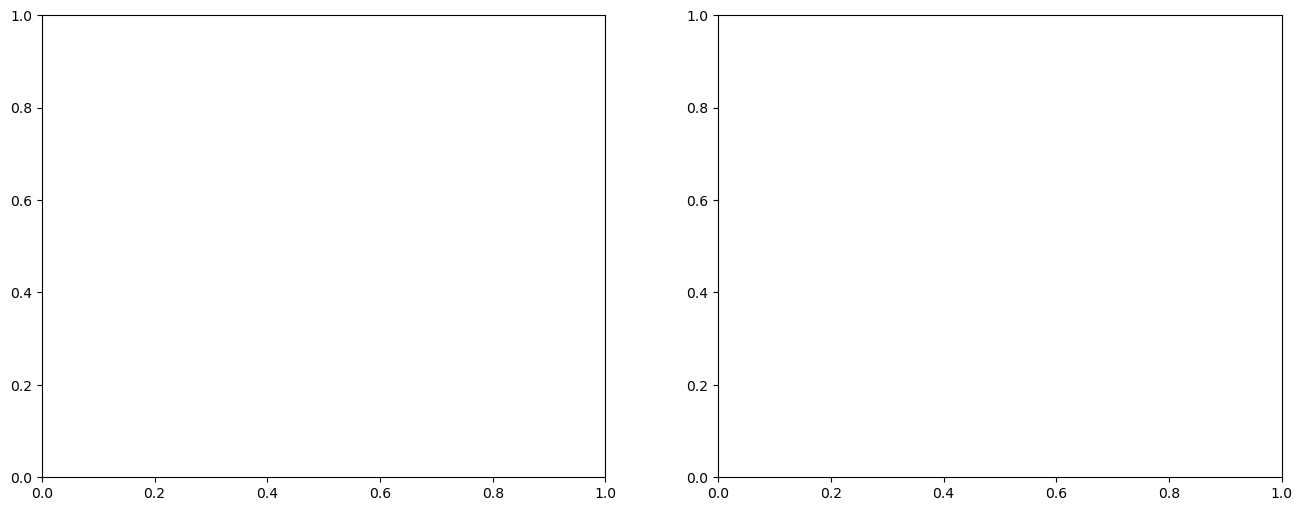

In [6]:
def make_heatmap(utilmat, tau, pop, title, ax):
    plotdata = utilmat.copy()
    finite_mask = np.isfinite(plotdata)
    if not np.any(finite_mask):
        ax.set_title(f'{title} — no finite values')
        return
    actual_min = np.nanmin(plotdata[finite_mask])
    actual_max = np.nanmax(plotdata[finite_mask])
    plotdata[np.isinf(plotdata)] = actual_min - 1
    jet = plt.cm.jet
    colors = [[1,1,1]] + jet(np.linspace(0,1,256)).tolist()
    cmap = LinearSegmentedColormap.from_list('custom', colors)
    Pop, Tau = np.meshgrid(pop, tau)
    im = ax.pcolormesh(Pop, Tau, plotdata, cmap=cmap, shading='auto')
    im.set_clim(actual_min-1, actual_max)
    ax.set_facecolor('black')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel('Population (billions)')
    ax.set_ylabel('Technology Level (τ)')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
make_heatmap(utilmat_spatial,  tau_grid, pop_grid, 'Spatial Model',   axes[0])
make_heatmap(utilmat_aspatial, tau_grid, pop_grid, 'Aspatial Model',  axes[1])
plt.suptitle('Utility Heatmap Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved to heatmap_comparison.png')

## 9. Save Results

In [ ]:
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
filename  = f'ECC_notebook_results_{timestamp}.npz'
np.savez_compressed(
    filename,
    utilmat_spatial=utilmat_spatial,
    utilmat_aspatial=utilmat_aspatial,
    tau=tau_grid,
    pop=pop_grid
)
print(f'saved to {filename}')

Check predictions

In [ ]:
# check income and substitution effects
tau = 0.0
pop = 8.0
H   = params['H'] * 1e9  # hectares
L   = params['lfpr'] * pop

conversion = tau * (0.123 - 0.123/2.5) + 0.123/2.5
harvest    = 1 - (tau * (0 - 0.5) + 0.5)

g_s = effective_par_from_g(
    compute_effective_g(kcal_per_ha, area_ha, farmedPct, sol_s[9], is_land), tau
) * 239.006 * 10000 * harvest * conversion

g_a = 2164.5 * 239.006 * 10000 * harvest * conversion

# food per capita directly from optimizer variables
h_f_s = sol_s[9] * (H / L)
h_f_a = sol_a[9] * (H / L)

F_pc_s = g_s * h_f_s * (sol_s[1])**p_spatial['alpha0'] * sol_s[4]**p_spatial['alpha1'] * (sol_s[7])**p_spatial['alpha2'] * params['lfpr']
F_pc_a = g_a * h_f_a * (sol_a[1])**p_aspatial['alpha0'] * sol_a[4]**p_aspatial['alpha1'] * (sol_a[7])**p_aspatial['alpha2'] * params['lfpr']

print(f'Food per capita spatial:  {F_pc_s:,.0f} kcal/yr')
print(f'Food per capita aspatial: {F_pc_a:,.0f} kcal/yr')
print(f'Minimum required:         {params["kcalmin"]:,.0f} kcal/yr')
print()
print(f'Land allocated to food:')
print(f'  Spatial:  {sol_s[9]*H/1e9:.3f} Gha ({sol_s[9]*100:.1f}% of H)')
print(f'  Aspatial: {sol_a[9]*H/1e9:.3f} Gha ({sol_a[9]*100:.1f}% of H)')
print(f'  Change:   {(sol_s[9]/sol_a[9] - 1)*100:.1f}%')
print()
print(f'Land allocated to goods:')
print(f'  Spatial:  {sol_s[8]*H/1e9:.3f} Gha ({sol_s[8]*100:.1f}% of H)')
print(f'  Aspatial: {sol_a[8]*H/1e9:.3f} Gha ({sol_a[8]*100:.1f}% of H)')
print(f'  Change:   {(sol_s[8]/sol_a[8] - 1)*100:.1f}%')
print()
print(f'Expected per advisor:')
print(f'  More calories: {F_pc_s > F_pc_a}')
print(f'  Less food land: {sol_s[9] < sol_a[9]}')
print(f'  More goods land: {sol_s[8] > sol_a[8]}')

# read kcalmin from params and check if caloric constraint is binding
print(f'Caloric constraint minimum: {params["kcalmin"]:,.0f} kcal/yr per capita')
print(f'h_food_share spatial:  {sol_s[9]:.4f}')
print(f'h_food_share aspatial: {sol_a[9]:.4f}')
print(f'h_food change: {(sol_s[9]/sol_a[9]-1)*100:.1f}%')
print()
print(f'Relative calorie production (proxy):')
print(f'  g_spatial * h_food_spatial:  {g_s * sol_s[9]:.4e}')
print(f'  g_aspatial * h_food_aspatial: {g_a * sol_a[9]:.4e}')
print(f'  Ratio: {(g_s * sol_s[9]) / (g_a * sol_a[9]):.4f}')
print(f'  More calories spatial: {(g_s * sol_s[9]) > (g_a * sol_a[9])}')

Food per capita spatial:  538,239,081,373,219 kcal/yr
Food per capita aspatial: 547,500,000,054,144 kcal/yr
Minimum required:         547,500 kcal/yr

Land allocated to food:
  Spatial:  1.049 Gha (21.3% of H)
  Aspatial: 1.198 Gha (24.4% of H)
  Change:   -12.5%

Land allocated to goods:
  Spatial:  2.124 Gha (43.2% of H)
  Aspatial: 2.037 Gha (41.5% of H)
  Change:   4.2%

Expected per advisor:
  More calories: False
  Less food land: True
  More goods land: True
Caloric constraint minimum: 547,500 kcal/yr per capita
h_food_share spatial:  0.2134
h_food_share aspatial: 0.2438
h_food change: -12.5%

Relative calorie production (proxy):
  g_spatial * h_food_spatial:  3.6091e+07
  g_aspatial * h_food_aspatial: 3.1027e+07
  Ratio: 1.1632
  More calories spatial: True
